# Introduction to Machine Learning: Deep Learning

**Instructor:** Daniel Acuna, Ph.D.
**Position:** Associate Professor of Computer Science
**Institution:** University of Colorado Boulder

---

Lab 2: Training and Regularizing Neural Networks

---

## Setup (do not edit)

In [1]:
import pathlib
from typing import Tuple, Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Suppress TensorFlow warnings for cleaner output
tf.get_logger().setLevel("ERROR")

RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Fashion-MNIST class names for reference
CLASS_NAMES: List[str] = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

_TRAIN_PATH = pathlib.Path("fashion_mnist_train.csv")
_TEST_PATH = pathlib.Path("fashion_mnist_test.csv")

if not _TRAIN_PATH.exists() or not _TEST_PATH.exists():
    raise FileNotFoundError(
        "Fashion-MNIST CSV files are missing from the lab directory. "
        "Please run the download script or ask the TA for assistance."
    )

## 1. Load and Explore the Dataset *(10 points)*

The Fashion-MNIST dataset contains 70,000 grayscale images of 10 clothing categories.
Each image is 28×28 pixels, flattened into 784 features.

Write a function `load_data()` that:
1. Reads the training CSV into a DataFrame
2. Returns the DataFrame

Store the shape of the training DataFrame in **`q1_shape`**.

In [2]:


def load_data(path: pathlib.Path) -> pd.DataFrame:
    """Load a Fashion-MNIST CSV file.

    Parameters
    ----------
    path : pathlib.Path
        Path to the CSV file.

    Returns
    -------
    pd.DataFrame
        DataFrame containing pixel values and labels.
    """
    
    df = pd.read_csv(path)
    return df


# Load training data and compute answer
train_df = load_data(_TRAIN_PATH)
q1_shape: Tuple[int, int] = train_df.shape

In [3]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 1
assert isinstance(q1_shape, tuple), (
    "q1_shape must be a tuple. Use df.shape which returns (rows, cols)."
)
assert len(q1_shape) == 2, (
    "q1_shape should have 2 elements (rows, cols)."
)
assert q1_shape[0] > 0 and q1_shape[1] > 0, (
    "Shape values must be positive. Is your CSV loading correctly?"
)
print(f"Training dataset shape: {q1_shape}")

Training dataset shape: (60000, 785)


## 2. Preprocess the Data *(10 points)*

Neural networks work best with normalized inputs. Prepare the data by:

1. Separating features (pixel columns) from the target (label column)
2. Normalizing pixel values to the range [0, 1] by dividing by 255
3. Splitting into train (60%), validation (20%), and test (20%) sets

Store:
- **`X_train`**, **`X_val`**, **`X_test`**: Normalized feature arrays
- **`y_train`**, **`y_val`**, **`y_test`**: Label arrays
- **`q2_split_counts`**: Tuple of (n_train, n_val, n_test)

**Hint:** Use `train_test_split` twice with `random_state=RANDOM_STATE`.

In [4]:
# Load test data as well
test_df = load_data(_TEST_PATH)

# seperate features and target
X = train_df.drop(columns = ['label']).values 
y = train_df['label'].values

X_test = test_df.drop(columns = ['label']).values
y_test = test_df['label'].values

# normalize to [0, 1]
X = X / 255.0

# Split 1, carve off 60% train, 40$ temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.4, random_state = RANDOM_STATE)


# Split 2, split the 40% temp evenly into val(20%?) and test(20%)
X_val, X_test, y_val, y_test = train_test_split( 
        X_temp, y_temp, test_size = 0.5, random_state = RANDOM_STATE
)



q2_split_counts: Tuple[int, int, int] = (len(X_train), len(X_val), len(X_test))
                                         

In [5]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 2
assert isinstance(q2_split_counts, tuple), (
    "q2_split_counts must be a tuple (n_train, n_val, n_test)."
)
assert len(q2_split_counts) == 3, "Tuple should have exactly 3 elements."
n_train, n_val, n_test = q2_split_counts
assert all(n > 0 for n in q2_split_counts), (
    "All splits must have positive sample counts."
)
assert n_train > n_val and n_train > n_test, (
    "Training set should be the largest. Check your split ratios."
)
assert X_train.max() <= 1.0 and X_train.min() >= 0.0, (
    "Pixel values should be normalized to [0, 1]. Did you divide by 255?"
)
print(f"Train/Val/Test split: {n_train} / {n_val} / {n_test}")

Train/Val/Test split: 36000 / 12000 / 12000


## 3. Build a Baseline Model (No Regularization) *(10 points)*

Build a neural network that is prone to overfitting (we'll fix it later!).

Architecture:
- **Input:** 784 features
- **Hidden Layer 1:** 256 neurons, ReLU activation
- **Hidden Layer 2:** 128 neurons, ReLU activation
- **Hidden Layer 3:** 64 neurons, ReLU activation
- **Output Layer:** 10 neurons, Softmax activation (for 10 classes)

Compile with:
- Optimizer: `'adam'`
- Loss: `'sparse_categorical_crossentropy'`
- Metrics: `['accuracy']`

Store the model in **`model_baseline`** and the parameter count in **`q3_n_params`**.

In [6]:
# Build sequential model with 3 hidden layers & 1 output layer
# In comments: HL = Hidden layer, n = neurons
model_baseline = Sequential([
    Dense(256, activation = 'relu', input_shape = (784,)), # HL1: 256n, 784 input features
    Dense(128, activation = 'relu'),                       # HL2: 128n 
    Dense(64, activation = 'relu'),                        # HL3: 64n
    Dense(10, activation = 'softmax'),         # Output layer: 10n(1 per class, softmax for probs)
])

# complie the model 
model_baseline.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

q3_n_params: int = model_baseline.count_params()


I0000 00:00:1789782165.163185  144292 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20865 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3e:00.0, compute capability: 8.9


In [7]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 3
assert isinstance(model_baseline, Sequential), (
    "model_baseline should be a Keras Sequential model."
)
assert isinstance(q3_n_params, (int, np.integer)), (
    "q3_n_params must be an integer. Use model.count_params()."
)
assert len(model_baseline.layers) == 4, (
    "Model should have 4 layers (3 hidden + 1 output)."
)
assert q3_n_params > 200000, (
    "This large model should have many parameters. Check your layer sizes."
)
print(f"Baseline model parameters: {q3_n_params:,}")

Baseline model parameters: 242,762


## 4. Train the Baseline Model *(10 points)*

Train the baseline model for **30 epochs** with `batch_size=128`.
Use the validation data to monitor performance.

Store:
- **`history_baseline`**: The training history object
- **`q4_final_val_acc`**: Final validation accuracy (last epoch), rounded to 3 decimals

After training, plot the training and validation accuracy curves.

In [8]:
# train the baseline model, 30 epochs with batch 128 using the validation set to monitor 
history_baseline = model_baseline.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 30,
    batch_size = 128,
    verbose = 1,
)

# Grab the final epochs validation acc and round to 3 decimal
q4_final_val_acc: float = round(history_baseline.history['val_accuracy'][-1], 3)


Epoch 1/30
107/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6347 - loss: 1.0753 

I0000 00:00:1789782185.721736  144499 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


282/282 ━━━━━━━━━━━━━━━━━━━━ 51s 112ms/step - accuracy: 0.7956 - loss: 0.5898 - val_accuracy: 0.8539 - val_loss: 0.4125
Epoch 2/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8538 - loss: 0.4088 - val_accuracy: 0.8636 - val_loss: 0.3832
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8675 - loss: 0.3629 - val_accuracy: 0.8679 - val_loss: 0.3606
Epoch 4/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8774 - loss: 0.3317 - val_accuracy: 0.8742 - val_loss: 0.3513
Epoch 5/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8857 - loss: 0.3100 - val_accuracy: 0.8792 - val_loss: 0.3325
Epoch 6/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8928 - loss: 0.2902 - val_accuracy: 0.8788 - val_loss: 0.3391
Epoch 7/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8988 - loss: 0.2746 - val_accuracy: 0.8831 - val_loss: 0.3220
Epoch 8/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9031 - loss: 0.2610 - val_accuracy: 0.8862 - v

In [9]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 4
assert hasattr(history_baseline, 'history'), (
    "history_baseline should be a Keras History object. Did you call model.fit()?"
)
assert 'accuracy' in history_baseline.history, (
    "History should contain 'accuracy'. Did you include metrics=['accuracy']?"
)
assert 'val_accuracy' in history_baseline.history, (
    "History should contain 'val_accuracy'. Did you pass validation_data?"
)
assert isinstance(q4_final_val_acc, float), (
    "q4_final_val_acc must be a float."
)
assert 0 <= q4_final_val_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
print(f"Final validation accuracy (baseline): {q4_final_val_acc:.3f}")

Final validation accuracy (baseline): 0.885


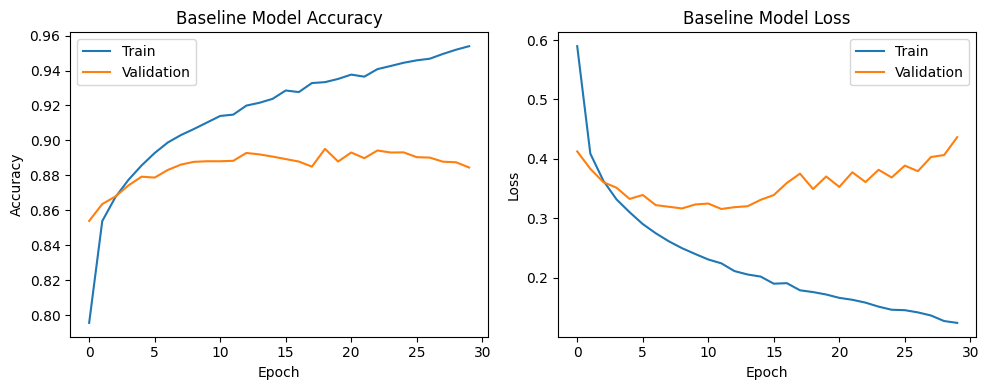

In [10]:
# Visualize baseline training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'], label='Train')
plt.plot(history_baseline.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Baseline Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'], label='Train')
plt.plot(history_baseline.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline Model Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Add L2 Regularization *(10 points)*

L2 regularization (weight decay) penalizes large weights, encouraging simpler models.

Build a new model with the **same architecture** as the baseline, but add
`kernel_regularizer=l2(0.001)` to each Dense layer (except the output layer).

Store:
- **`model_l2`**: The L2-regularized model
- **`q5_l2_val_acc`**: Final validation accuracy after 30 epochs, rounded to 3 decimals

In [11]:
# Build same as baseline (Q3), but with L2 regularization on hidden layers
model_l2 = Sequential([
    Dense(256, activation = 'relu', kernel_regularizer = l2(0.001), input_shape = (784,)),
    Dense(128, activation = 'relu', kernel_regularizer = l2(0.001)),                      
    Dense(64, activation = 'relu', kernel_regularizer = l2(0.001)),                       
    Dense(10, activation = 'softmax'),         
])

model_l2.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'],
)

history_l2 = model_l2.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 30,
    batch_size = 128,
    verbose = 1,
)

q5_l2_val_acc: float = round(history_l2.history['val_accuracy'][-1], 3)

Epoch 1/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7896 - loss: 1.0311 - val_accuracy: 0.8448 - val_loss: 0.7620
Epoch 2/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8438 - loss: 0.7206 - val_accuracy: 0.8586 - val_loss: 0.6461
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8559 - loss: 0.6321 - val_accuracy: 0.8651 - val_loss: 0.5848
Epoch 4/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8622 - loss: 0.5763 - val_accuracy: 0.8723 - val_loss: 0.5485
Epoch 5/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8680 - loss: 0.5410 - val_accuracy: 0.8721 - val_loss: 0.5267
Epoch 6/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8716 - loss: 0.5150 - val_accuracy: 0.8755 - val_loss: 0.5046
Epoch 7/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8745 - loss: 0.4950 - val_accuracy: 0.8786 - val_loss: 0.4855
Epoch 8/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8767 - loss: 0.4804 - val_accuracy: 0

In [12]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 5
assert isinstance(model_l2, Sequential), (
    "model_l2 should be a Keras Sequential model."
)
assert isinstance(q5_l2_val_acc, float), (
    "q5_l2_val_acc must be a float."
)
assert 0 <= q5_l2_val_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
# Check that L2 regularization is applied
has_l2 = any(
    layer.kernel_regularizer is not None 
    for layer in model_l2.layers 
    if hasattr(layer, 'kernel_regularizer')
)
assert has_l2, (
    "Model should have L2 regularization. Use kernel_regularizer=l2(0.001)."
)
print(f"L2 Regularized model validation accuracy: {q5_l2_val_acc:.3f}")

L2 Regularized model validation accuracy: 0.884


## 6. Add Dropout *(10 points)*

Dropout randomly sets a fraction of activations to zero during training,
preventing co-adaptation of neurons.

Build a new model with the **same architecture**, but add `Dropout(0.3)` layers
after each hidden Dense layer (not after the output layer).

Store:
- **`model_dropout`**: The dropout model
- **`q6_dropout_val_acc`**: Final validation accuracy after 30 epochs, rounded to 3 decimals

In [13]:
# Build the same architecture but this time add Dropout(0.3) after each Hidden dense layer
model_dropout = Sequential([
    Dense(256, activation = 'relu', input_shape = (784,)), 
    Dropout(0.3),
    Dense(128, activation = 'relu'),     
    Dropout(0.3),
    Dense(64, activation = 'relu'),                     
    Dropout(0.3),
    Dense(10, activation = 'softmax'),         
])

model_dropout.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)    

history_dropout = model_dropout.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 30,
    batch_size = 128,
    verbose = 1,
)

q6_dropout_val_acc: float = round(history_dropout.history['val_accuracy'][-1], 3)

Epoch 1/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 36s 61ms/step - accuracy: 0.7059 - loss: 0.8227 - val_accuracy: 0.8342 - val_loss: 0.4720
Epoch 2/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8139 - loss: 0.5304 - val_accuracy: 0.8587 - val_loss: 0.3969
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8354 - loss: 0.4690 - val_accuracy: 0.8646 - val_loss: 0.3716
Epoch 4/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8464 - loss: 0.4352 - val_accuracy: 0.8708 - val_loss: 0.3569
Epoch 5/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8523 - loss: 0.4108 - val_accuracy: 0.8737 - val_loss: 0.3448
Epoch 6/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8572 - loss: 0.3941 - val_accuracy: 0.8782 - val_loss: 0.3395
Epoch 7/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8629 - loss: 0.3833 - val_accuracy: 0.8734 - val_loss: 0.3405
Epoch 8/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8679 - loss: 0.3679 - val_accuracy: 

In [14]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 6
assert isinstance(model_dropout, Sequential), (
    "model_dropout should be a Keras Sequential model."
)
assert isinstance(q6_dropout_val_acc, float), (
    "q6_dropout_val_acc must be a float."
)
assert 0 <= q6_dropout_val_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
# Check that Dropout layers are present
has_dropout = any(isinstance(layer, Dropout) for layer in model_dropout.layers)
assert has_dropout, (
    "Model should have Dropout layers. Add Dropout(0.3) after Dense layers."
)
print(f"Dropout model validation accuracy: {q6_dropout_val_acc:.3f}")

Dropout model validation accuracy: 0.889


## 7. Implement Early Stopping *(10 points)*

Early stopping monitors validation loss and stops training when it stops improving,
preventing overfitting by not training too long.

Build the **same baseline architecture** (no regularization) but train it with
an `EarlyStopping` callback:
- Monitor: `'val_loss'`
- Patience: `5` (wait 5 epochs before stopping)
- `restore_best_weights=True`

Train for a maximum of **100 epochs** (early stopping will likely stop sooner).

Store:
- **`model_early_stop`**: The model trained with early stopping
- **`q7_stopped_epoch`**: The epoch at which training stopped (integer)
- **`q7_early_val_acc`**: Final validation accuracy, rounded to 3 decimals

In [15]:
# Almost the same as #6
#    same baseline architecture, no regularization, but train w/ earlystopping
model_early_stop = Sequential([
    Dense(256, activation = 'relu', input_shape = (784,)), 
    Dropout(0.3),
    Dense(128, activation = 'relu'),     
    Dropout(0.3),
    Dense(64, activation = 'relu'),                     
    Dropout(0.3),
    Dense(10, activation = 'softmax'),         
])

model_early_stop.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)    

early_stop_cb = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

history_early = model_early_stop.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 100,
    batch_size = 128,
    callbacks = [early_stop_cb],
    verbose = 1,
)

#stopped_epoch is 0 indexed when triggered, +1 give the actual epoch count
#   if training ran the full 100 without stop, len(hisotry) gives the true count
if early_stop_cb.stopped_epoch > 0:
    q7_stopped_epoch: int = early_stop_cb.stopped_epoch + 1
else: 
    q7_stopped_epoch: int = len(history_early.history['loss'])

q7_early_val_acc: float = round(history_early.history['val_accuracy'][-1], 3)


Epoch 1/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7014 - loss: 0.8356 - val_accuracy: 0.8380 - val_loss: 0.4559
Epoch 2/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8139 - loss: 0.5287 - val_accuracy: 0.8566 - val_loss: 0.4041
Epoch 3/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8361 - loss: 0.4683 - val_accuracy: 0.8637 - val_loss: 0.3747
Epoch 4/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8449 - loss: 0.4380 - val_accuracy: 0.8697 - val_loss: 0.3579
Epoch 5/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8544 - loss: 0.4095 - val_accuracy: 0.8725 - val_loss: 0.3479
Epoch 6/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8620 - loss: 0.3895 - val_accuracy: 0.8726 - val_loss: 0.3439
Epoch 7/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8631 - loss: 0.3839 - val_accuracy: 0.8783 - val_loss: 0.3358
Epoch 8/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8692 - loss: 0.3657 - val_acc

In [16]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 7
assert isinstance(model_early_stop, Sequential), (
    "model_early_stop should be a Keras Sequential model."
)
assert isinstance(q7_stopped_epoch, (int, np.integer)), (
    "q7_stopped_epoch must be an integer."
)
assert isinstance(q7_early_val_acc, float), (
    "q7_early_val_acc must be a float."
)
assert q7_stopped_epoch < 100, (
    "Early stopping should have stopped before 100 epochs. "
    "Check your EarlyStopping callback configuration."
)
assert q7_stopped_epoch > 5, (
    "Training stopped too early. Make sure patience=5."
)
print(f"Training stopped at epoch: {q7_stopped_epoch}")
print(f"Early stopping validation accuracy: {q7_early_val_acc:.3f}")

Training stopped at epoch: 34
Early stopping validation accuracy: 0.894


## 8. Add Batch Normalization *(10 points)*

Batch Normalization normalizes layer inputs, which stabilizes training and can
act as mild regularization.

Build a new model with BatchNormalization after each Dense layer (before activation):
- Dense(256) → BatchNormalization → ReLU (use `activation=None` in Dense, then separate layer)
- Or simpler: Dense(256, activation='relu') → BatchNormalization (after activation)

Use the simpler approach: add `BatchNormalization()` after each hidden Dense+ReLU layer.

Store:
- **`model_batchnorm`**: The batch-normalized model
- **`q8_batchnorm_val_acc`**: Final validation accuracy after 30 epochs, rounded to 3 decimals

In [17]:
# This one is similar to Q2, same architecture but adding batchnormalization
model_batchnorm = Sequential([
    Dense(256, activation = 'relu', input_shape = (784,)), 
    BatchNormalization(),
    Dense(128, activation = 'relu'),     
    BatchNormalization(),
    Dense(64, activation = 'relu'),                     
    BatchNormalization(),
    Dense(10, activation = 'softmax'),         
])

model_batchnorm.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history_batchnorm = model_batchnorm.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 30,
    batch_size = 128,
    verbose = 1,
)

q8_batchnorm_val_acc: float = round(history_batchnorm.history['val_accuracy'][-1], 3)

Epoch 1/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.8249 - loss: 0.5011 - val_accuracy: 0.8209 - val_loss: 0.4780
Epoch 2/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8676 - loss: 0.3636 - val_accuracy: 0.8370 - val_loss: 0.4122
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8820 - loss: 0.3221 - val_accuracy: 0.8252 - val_loss: 0.4461
Epoch 4/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8891 - loss: 0.3000 - val_accuracy: 0.8477 - val_loss: 0.4292
Epoch 5/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8967 - loss: 0.2799 - val_accuracy: 0.8619 - val_loss: 0.3941
Epoch 6/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9007 - loss: 0.2672 - val_accuracy: 0.8401 - val_loss: 0.4355
Epoch 7/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9089 - loss: 0.2480 - val_accuracy: 0.8738 - val_loss: 0.3604
Epoch 8/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9139 - loss: 0.2343 - val_accuracy: 

In [18]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 8
assert isinstance(model_batchnorm, Sequential), (
    "model_batchnorm should be a Keras Sequential model."
)
assert isinstance(q8_batchnorm_val_acc, float), (
    "q8_batchnorm_val_acc must be a float."
)
assert 0 <= q8_batchnorm_val_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
# Check that BatchNormalization layers are present
has_batchnorm = any(isinstance(layer, BatchNormalization) for layer in model_batchnorm.layers)
assert has_batchnorm, (
    "Model should have BatchNormalization layers."
)
print(f"Batch Normalization model validation accuracy: {q8_batchnorm_val_acc:.3f}")

Batch Normalization model validation accuracy: 0.873


## 9. Compare All Models on Test Set *(10 points)*

Evaluate all five models on the **test set** and compare their performance.

Store a dictionary **`q9_test_accuracies`** with keys:
- `'baseline'`: Test accuracy of baseline model
- `'l2'`: Test accuracy of L2 regularized model
- `'dropout'`: Test accuracy of dropout model
- `'early_stopping'`: Test accuracy of early stopping model
- `'batchnorm'`: Test accuracy of batch normalization model

All values should be floats rounded to 3 decimals.

Also store **`q9_best_model`**: The key of the model with highest test accuracy.

In [19]:
# Eval each model on the held out test set
models = {
    'baseline': model_baseline,
    'l2': model_l2,
    'dropout': model_dropout,
    'early_stopping': model_early_stop,
    'batchnorm': model_batchnorm
}

q9_test_accuracies: Dict[str, float] = {}
for key, model in models.items():
    _, test_acc = model.evaluate(X_test, y_test, verbose = 0)
    q9_test_accuracies[key] = round(float(test_acc), 3)
    
q9_best_model: str = max(q9_test_accuracies, key = q9_test_accuracies.get)
    

In [20]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 9
assert isinstance(q9_test_accuracies, dict), (
    "q9_test_accuracies must be a dictionary."
)
expected_keys = {'baseline', 'l2', 'dropout', 'early_stopping', 'batchnorm'}
assert set(q9_test_accuracies.keys()) == expected_keys, (
    f"Dictionary should have keys: {expected_keys}. Got: {set(q9_test_accuracies.keys())}"
)
for key, val in q9_test_accuracies.items():
    assert isinstance(val, float), f"Value for '{key}' must be a float."
    assert 0 <= val <= 1, f"Accuracy for '{key}' must be between 0 and 1."
assert isinstance(q9_best_model, str), (
    "q9_best_model must be a string (the model name)."
)
assert q9_best_model in expected_keys, (
    f"q9_best_model must be one of {expected_keys}."
)
print("Test Accuracies:")
for name, acc in q9_test_accuracies.items():
    print(f"  {name}: {acc:.3f}")
print(f"\nBest model: {q9_best_model}")

Test Accuracies:
  baseline: 0.877
  l2: 0.871
  dropout: 0.884
  early_stopping: 0.889
  batchnorm: 0.870

Best model: early_stopping


## 10. Analyze Overfitting Gap *(10 points)*

The **overfitting gap** is the difference between training accuracy and validation accuracy.
A large gap indicates the model is memorizing training data rather than learning general patterns.

For each model, compute the overfitting gap using the **final epoch's** accuracies:
`gap = train_accuracy - val_accuracy`

Store a dictionary **`q10_overfit_gaps`** with the same keys as above.
All values should be floats rounded to 3 decimals.

Also store **`q10_least_overfit`**: The key of the model with the **smallest** overfitting gap.

In [21]:
# For each model, compute the overfitting gap = final epoch train_accuracy - val_accuracy
q10_overfit_gaps: Dict[str, float] = {
    'baseline': 
    round(history_baseline.history['accuracy'][-1] - history_baseline.history['val_accuracy'][-1], 3),
    
    'l2': 
     round(history_l2.history['accuracy'][-1] - history_l2.history['val_accuracy'][-1], 3),
    
    'dropout': 
    round(history_dropout.history['accuracy'][-1] - history_dropout.history['val_accuracy'][-1], 3),
    
    'early_stopping': 
    round(history_early.history['accuracy'][-1] - history_early.history['val_accuracy'][-1], 3),
    
    'batchnorm': 
    round(history_batchnorm.history['accuracy'][-1] - history_batchnorm.history['val_accuracy'][-1], 3)
}

# Model with the smallest overfitting gap
q10_least_overfit: str = min(q10_overfit_gaps, key = q10_overfit_gaps.get)



In [22]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 10
assert isinstance(q10_overfit_gaps, dict), (
    "q10_overfit_gaps must be a dictionary."
)
expected_keys = {'baseline', 'l2', 'dropout', 'early_stopping', 'batchnorm'}
assert set(q10_overfit_gaps.keys()) == expected_keys, (
    f"Dictionary should have keys: {expected_keys}."
)
for key, val in q10_overfit_gaps.items():
    assert isinstance(val, float), f"Value for '{key}' must be a float."
assert isinstance(q10_least_overfit, str), (
    "q10_least_overfit must be a string (the model name)."
)
assert q10_least_overfit in expected_keys, (
    f"q10_least_overfit must be one of {expected_keys}."
)
print("Overfitting Gaps (Train Acc - Val Acc):")
for name, gap in q10_overfit_gaps.items():
    print(f"  {name}: {gap:.3f}")
print(f"\nLeast overfitting model: {q10_least_overfit}")

Overfitting Gaps (Train Acc - Val Acc):
  baseline: 0.069
  l2: 0.021
  dropout: 0.012
  early_stopping: 0.010
  batchnorm: 0.098

Least overfitting model: early_stopping


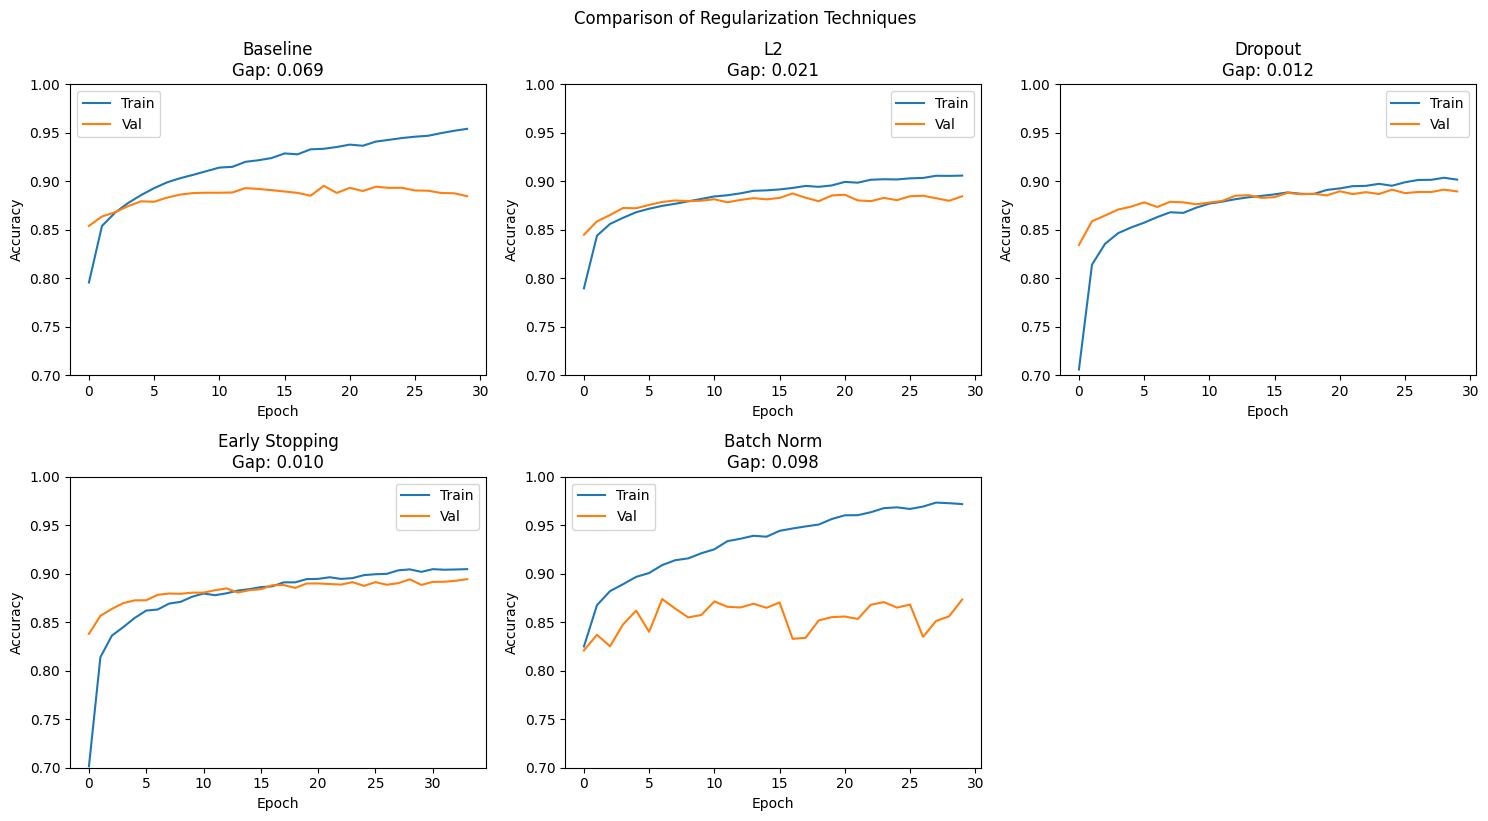

In [23]:
# Visualization: Compare all models
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

histories = {
    'Baseline': history_baseline,
    'L2': history_l2,
    'Dropout': history_dropout,
    'Early Stopping': history_early,
    'Batch Norm': history_batchnorm
}

for idx, (name, hist) in enumerate(histories.items()):
    ax = axes[idx // 3, idx % 3]
    ax.plot(hist.history['accuracy'], label='Train')
    ax.plot(hist.history['val_accuracy'], label='Val')
    ax.set_title(f'{name}\nGap: {hist.history["accuracy"][-1] - hist.history["val_accuracy"][-1]:.3f}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.set_ylim([0.7, 1.0])

# Hide the 6th subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.suptitle('Comparison of Regularization Techniques', y=1.02)
plt.show()

## Next Steps

Congratulations on completing the assignment! Before submitting:

1. Make sure all your cells run without errors.
2. Ensure you've answered all parts of each question.
3. If any autograder tests fail, revisit your answers.
